In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

print("CUDA_VISIBLE_DEVICES:", os.environ["CUDA_VISIBLE_DEVICES"])

CUDA_VISIBLE_DEVICES: -1


In [2]:
import tensorflow as tf

print(tf.config.list_physical_devices("GPU"))

I0000 00:00:1788373784.908732 3881903 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788373784.940013 3881903 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788373785.568104 3881903 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[]


E0000 00:00:1788373786.145383 3881903 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1788373786.145407 3881903 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1788373786.145415 3881903 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1788373786.145422 3881903 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1788373786.145423 3881903 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: TECHPARK2
I0000 00:00:1788373786.145425 3881903 cuda_diagnostics.cc:183] hostname: TECHPARK2
I0000 00:00:1788373786.145477 3881903 cuda_diagnostics.cc:190] libcuda reported version is: 595.84.0
I0000 00:00:1788373786.145485 3881903 cuda_diagnostics.cc:194] kernel rep

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [4]:
file_path = "/home/techpark-2/Desktop/radiation/dataset/proton_1_500MeV_clean.csv"

df = pd.read_csv(file_path)

df["time"] = pd.to_datetime(df["time"])

df = df.sort_values("time")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Rows: 1736640
Columns: 14


,time,1.02_1.86_MeV,1.9_2.3_MeV,2.31_3.34_MeV,3.4_6.48_MeV,5.84_11_MeV,11.64_23.27_MeV,23.9_32.6_MeV,40.7_68.2_MeV,83.9_98.4_MeV,99.7_118_MeV,123_148_MeV,156_237_MeV,267_390_MeV
0,2022-09-13 00:00:00,0.035267,0.009745,0.003481,0.000167,0.000181,0.000123,0.000021,0.000005,0.000000e+00,0.000001,0.000003,1.385365e-06,3.103786e-07
1,2022-09-13 00:01:00,0.036756,0.012085,0.003330,0.000056,0.000000,0.000098,0.000038,0.000001,0.000000e+00,0.000000,0.000003,1.385347e-06,1.034578e-07
2,2022-09-13 00:02:00,0.032474,0.007404,0.003481,0.000111,0.000060,0.000160,0.000038,0.000004,0.000000e+00,0.000000,0.000003,1.847152e-06,2.069206e-07
3,2022-09-13 00:03:00,0.033030,0.012080,0.004086,0.000167,0.000242,0.000049,0.000048,0.000005,5.671780e-07,0.000002,0.000004,4.617816e-07,4.138364e-07
4,2022-09-13 00:04:00,0.033216,0.013639,0.003329,0.000111,0.000030,0.000086,0.000024,0.000011,5.671729e-07,0.000002,0.000002,6.926708e-07,3.103777e-07


In [10]:
import numpy as np

# Keep ONLY the 13 energy channels
features = df.columns[1:].tolist()

print("Number of features:", len(features))
print("Features:")
for i, feature in enumerate(features):
    print(i, feature)

# Convert only numeric energy columns
data = df[features].to_numpy(dtype=np.float32)

print("\nData shape:", data.shape)
print("Data type:", data.dtype)

Number of features: 13
Features:
0 1.02_1.86_MeV
1 1.9_2.3_MeV
2 2.31_3.34_MeV
3 3.4_6.48_MeV
4 5.84_11_MeV
5 11.64_23.27_MeV
6 23.9_32.6_MeV
7 40.7_68.2_MeV
8 83.9_98.4_MeV
9 99.7_118_MeV
10 123_148_MeV
11 156_237_MeV
12 267_390_MeV

Data shape: (1736640, 13)
Data type: float32


In [17]:
n = len(data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

Train: (1215648, 13)
Validation: (260496, 13)
Test: (260496, 13)


In [18]:
EPSILON = 1e-12

train_log = np.log10(train_data + EPSILON)
val_log = np.log10(val_data + EPSILON)
test_log = np.log10(test_data + EPSILON)

In [19]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_log)

val_scaled = scaler.transform(val_log)
test_scaled = scaler.transform(test_log)

print(train_scaled.min())
print(train_scaled.max())

0.0
1.0000001


In [20]:
LOOKBACK = 60

In [21]:
def create_sequences(data, lookback):
    X = []
    y = []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [22]:

X_test, y_test = create_sequences(test_scaled, LOOKBACK)

In [23]:
from tensorflow import keras
model = keras.models.load_model("/home/techpark-2/Desktop/radiation/model1/saved_model/trained_model01.keras")

In [24]:
Y_pred = model.predict(X_test)

8139/8139 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step


In [25]:
Y_pred.shape

(260436, 13)

In [35]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score
)

# Make sure shapes match
print("y_test :", y_test.shape)
print("Y_pred :", Y_pred.shape)

# Overall metrics
mae = mean_absolute_error(y_test, Y_pred)
mse = mean_squared_error(y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, Y_pred)
ev = explained_variance_score(y_test, Y_pred)

print("\n===== TEST EVALUATION =====")
print(f"MAE                 : {mae:.6f}")
print(f"MSE                 : {mse:.6f}")
print(f"RMSE                : {rmse:.6f}")
print(f"R²                  : {r2:.6f}")
print(f"Explained Variance  : {ev:.6f}")

# Per energy-channel evaluation
features = df.columns[1:].tolist()

results = []

for i, feature in enumerate(features):
    mae_i = mean_absolute_error(y_test[:, i], Y_pred[:, i])
    mse_i = mean_squared_error(y_test[:, i], Y_pred[:, i])
    rmse_i = np.sqrt(mse_i)
    r2_i = r2_score(y_test[:, i], Y_pred[:, i])
    ev_i = explained_variance_score(y_test[:, i], Y_pred[:, i])

    results.append([
        feature,
        mae_i,
        mse_i,
        rmse_i,
        r2_i,
        ev_i
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Energy Channel",
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "Explained Variance"
    ]
)

print("\n===== PER-CHANNEL EVALUATION =====")
print(results_df.to_string(index=False))

y_test : (260436, 13)
Y_pred : (260436, 13)

===== TEST EVALUATION =====
MAE                 : 0.104886
MSE                 : 0.032846
RMSE                : 0.181234
R²                  : -123.282104
Explained Variance  : -41.251022

===== PER-CHANNEL EVALUATION =====
 Energy Channel      MAE      MSE     RMSE            R2  Explained Variance
  1.02_1.86_MeV 0.059055 0.014361 0.119837  5.955603e-01        6.007388e-01
    1.9_2.3_MeV 0.133324 0.038698 0.196718  6.344869e-01        6.351122e-01
  2.31_3.34_MeV 0.136032 0.039466 0.198661  6.106695e-01        6.113136e-01
   3.4_6.48_MeV 0.138246 0.037245 0.192990  5.909517e-01        5.923030e-01
    5.84_11_MeV 0.214920 0.063461 0.251914  3.508942e-01        3.521584e-01
11.64_23.27_MeV 0.276446 0.088180 0.296950  1.439694e-01        1.444495e-01
  23.9_32.6_MeV 0.002797 0.000014 0.003681  0.000000e+00        0.000000e+00
  40.7_68.2_MeV 0.004648 0.000030 0.005490 -8.484361e+09       -2.956003e+09
  83.9_98.4_MeV 0.006130 0.000052 0.00

In [36]:
for i, feature in enumerate(features):
    actual_std = np.std(y_test[:, i])
    actual_mean = np.mean(y_test[:, i])

    print(
        f"{feature:20s} "
        f"mean={actual_mean:.8f} "
        f"std={actual_std:.8f}"
    )

1.02_1.86_MeV        mean=0.64366519 std=0.18843552
1.9_2.3_MeV          mean=0.24838419 std=0.32538113
2.31_3.34_MeV        mean=0.25007829 std=0.31838542
3.4_6.48_MeV         mean=0.20786095 std=0.30174980
5.84_11_MeV          mean=0.24098618 std=0.31267607
11.64_23.27_MeV      mean=0.43079472 std=0.32095143
23.9_32.6_MeV        mean=0.00000000 std=0.00000000
40.7_68.2_MeV        mean=0.73129642 std=0.00000006
83.9_98.4_MeV        mean=0.79571635 std=0.00000018
99.7_118_MeV         mean=0.88227266 std=0.00000000
123_148_MeV          mean=0.87479568 std=0.00000012
156_237_MeV          mean=0.81781960 std=0.00000018
267_390_MeV          mean=0.35823238 std=0.38562849


In [37]:
for i, feature in enumerate(features):
    print(
        f"{feature:20s} "
        f"Actual mean={np.mean(y_test[:, i]):.6f}, "
        f"Pred mean={np.mean(Y_pred[:, i]):.6f}"
    )

1.02_1.86_MeV        Actual mean=0.643665, Pred mean=0.630105
1.9_2.3_MeV          Actual mean=0.248384, Pred mean=0.240247
2.31_3.34_MeV        Actual mean=0.250078, Pred mean=0.241998
3.4_6.48_MeV         Actual mean=0.207861, Pred mean=0.218953
5.84_11_MeV          Actual mean=0.240986, Pred mean=0.252103
11.64_23.27_MeV      Actual mean=0.430795, Pred mean=0.423762
23.9_32.6_MeV        Actual mean=0.000000, Pred mean=-0.001511
40.7_68.2_MeV        Actual mean=0.731296, Pred mean=0.726865
83.9_98.4_MeV        Actual mean=0.795716, Pred mean=0.790319
99.7_118_MeV         Actual mean=0.882273, Pred mean=0.886255
123_148_MeV          Actual mean=0.874796, Pred mean=0.868390
156_237_MeV          Actual mean=0.817820, Pred mean=0.818371
267_390_MeV          Actual mean=0.358232, Pred mean=0.384561


**EVALUATION METRICS**

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score
)
import numpy as np 

Y_pred = np.asarray(Y_pred)
y_test = np.asarray(y_test)


**MEAN SQUARED ERROR**

In [28]:
mse = mean_squared_error(y_test,Y_pred)
mse

0.032845787703990936

**MEAN ABSOLUTE ERROR**

In [29]:
mae = mean_absolute_error(y_test,Y_pred)
mae

0.10488605499267578

**RMSE - Root Mean Squared Error** 

In [30]:
rmse = np.sqrt(mse)
rmse

np.float64(0.18123406882810675)

**R2 Score**

In [31]:
r2 = r2_score(y_test,Y_pred)
r2

-123.2821044921875

**Explained Variance Score**

In [32]:
ev = explained_variance_score(y_test, Y_pred)
ev

-41.25102233886719

**GRAPHS**

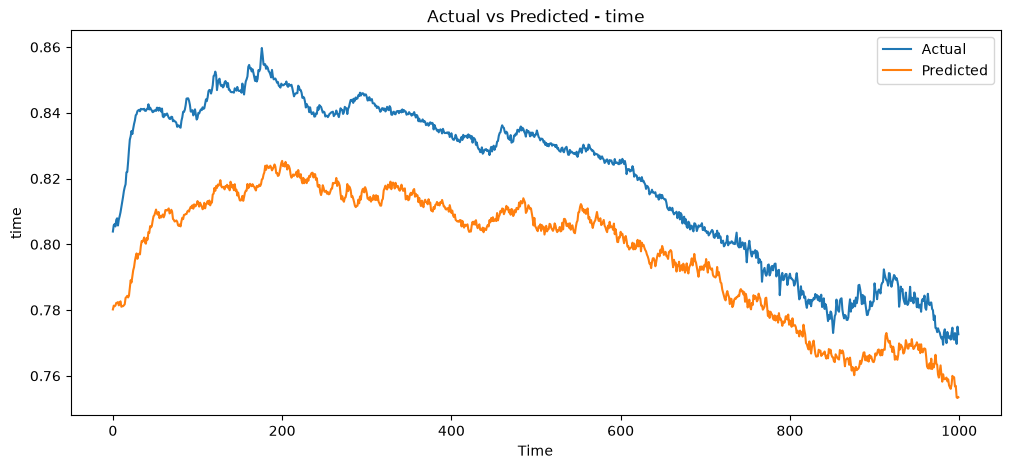

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_test[:1000, 0], label="Actual")
plt.plot(Y_pred[:1000, 0], label="Predicted")

plt.xlabel("Time")
plt.ylabel(features[0])
plt.title(f"Actual vs Predicted - {features[0]}")
plt.legend()
plt.show()